In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-04-26 17:55:42.743171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777226142.948011      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777226143.015181      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777226143.535208      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777226143.535275      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777226143.535278      23 computation_placer.cc:177] computation placer alr

In [3]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=09567ad8aa217078e6ca71df1fd56f62c391c0b7016910d334beeed38977a8a4
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-04-26 17:56:26--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M   169MB/s    in 0.2s    

2026-04-26 17:56:27 (169 MB/s) - ‘VnCoreNLP

In [4]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [ ]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu


In [7]:
train_df

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,1,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1
11422,em cảm ơn cô nhiều .,2,0
11423,giao bài tập quá nhiều .,0,0
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['sentence'].apply(word_segment)
val_df['sentence_seg'] = val_df['sentence'].apply(word_segment)
test_df['sentence_seg'] = test_df['sentence'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,sentence_seg
0,slide giáo trình đầy đủ .,2,1,slide giáo_trình đầy_đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,"nhiệt_tình giảng_dạy , gần_gũi với sinh_viên ."
2,đi học đầy đủ full điểm chuyên cần .,1,1,đi học đầy_đủ full điểm chuyên_cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,"thầy giảng bài hay , có nhiều bài_tập ví_dụ ng..."


# B0a Single task sentiment
# B0b Single task topic
# B1 MTL Hard Sharing + CE
# B2 MTL + Cross-Task + CE + Label Smoothing=0.1 + Dropout=0.3
# B3 MTL Cross-task + Focal Loss 

In [ ]:
# config
MODEL_NAME   = "vinai/phobert-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
LR           = 2e-5
LR_ENCODER   = 2e-5   
LR_HEADS     = 1e-4   # LR cho Classification Heads và Cross-Attention
DROPOUT      = 0.3    
EPOCHS       = 20
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE      = 5       
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]
 
print(f"Device : {DEVICE}")
print(f"Encoder: {MODEL_NAME}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }

def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        # df["sentence"].tolist(),
        df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test cho MTL
def diagnose_validation(model, val_loader, model_name):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số"""
    model.eval()
    s_preds, s_labels, t_preds, t_labels = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            s_logit, t_logit = model(ids, mask)
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    print(f"\nChấn đoán trên validation === {model_name} ===")
    print("SENTIMENT:")
    print(classification_report(s_labels, s_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))
    print("TOPIC:")
    print(classification_report(t_labels, t_preds, target_names=["Lecturer", "Training", "Facility", "Others"], digits=4))

# Chẩn đoán trên tập val trước khi lưu test cho STL
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device : cuda
Encoder: vinai/phobert-base


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166
Sentiment weights: tensor([0.2240, 2.5650, 0.2110])
Topic weights    : tensor([0.1020, 0.3730, 1.6630, 1.8620])
Focal alpha  (sentiment): [0.0747 0.8551 0.0702]
Focal alpha  (topic)    : [0.0256 0.0932 0.4157 0.4654]



B0a: Sentiment Baseline


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.5392 | Val Loss: 0.1906 | Train F1: 0.5581 | Val F1: 0.6572
New best (Val F1: 0.6572)
Epoch 02 | Train Loss: 0.1715 | Val Loss: 0.1854 | Train F1: 0.7965 | Val F1: 0.7918
New best (Val F1: 0.7918)
Epoch 03 | Train Loss: 0.1251 | Val Loss: 0.1662 | Train F1: 0.8642 | Val F1: 0.8279
New best (Val F1: 0.8279)
Epoch 04 | Train Loss: 0.0871 | Val Loss: 0.1521 | Train F1: 0.9108 | Val F1: 0.8672
New best (Val F1: 0.8672)
Epoch 05 | Train Loss: 0.0563 | Val Loss: 0.1826 | Train F1: 0.9387 | Val F1: 0.8691
New best (Val F1: 0.8691)
Epoch 06 | Train Loss: 0.0409 | Val Loss: 0.2503 | Train F1: 0.9556 | Val F1: 0.8440
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0394 | Val Loss: 0.2218 | Train F1: 0.9631 | Val F1: 0.8654
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0201 | Val Loss: 0.2338 | Train F1: 0.9821 | Val F1: 0.8525
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.8691


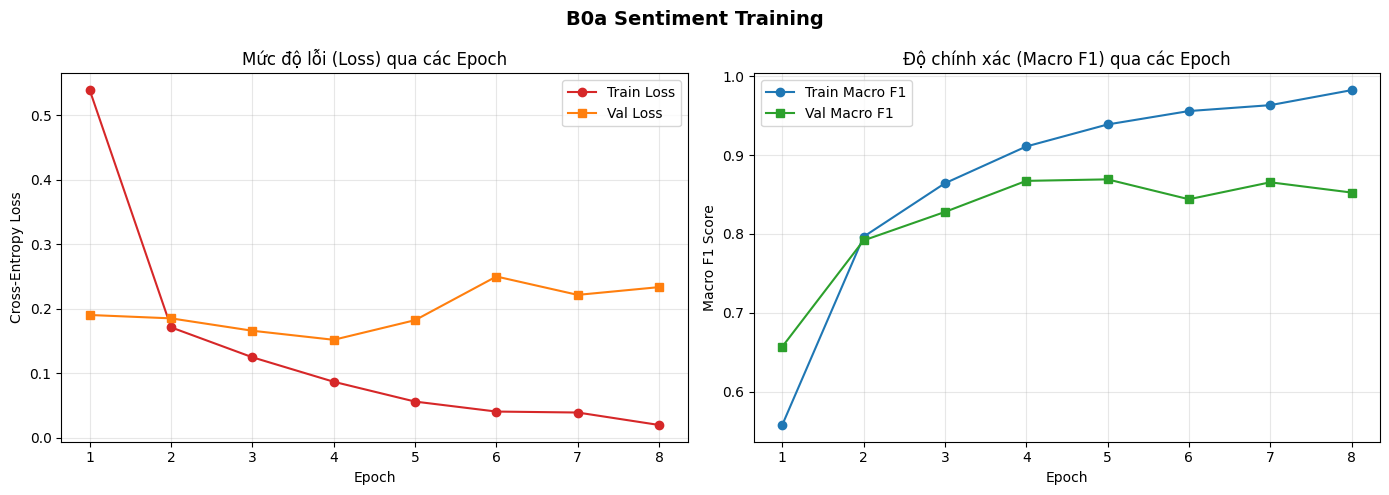


Chẩn đoán validation === B0a Single Sentiment (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9606    0.9813    0.9708       695
     Neutral     0.7424    0.5904    0.6577        83
    Positive     0.9777    0.9801    0.9789       805

    accuracy                         0.9602      1583
   macro avg     0.8936    0.8506    0.8691      1583
weighted avg     0.9578    0.9602    0.9585      1583


=== B0A SENTIMENT ===
              precision    recall  f1-score   support

    Negative     0.9562    0.9595    0.9578      1409
     Neutral     0.6533    0.5868    0.6183       167
    Positive     0.9513    0.9585    0.9549      1590

    accuracy                         0.9394      3166
   macro avg     0.8536    0.8350    0.8437      3166
weighted avg     0.9377    0.9394    0.9384      3166



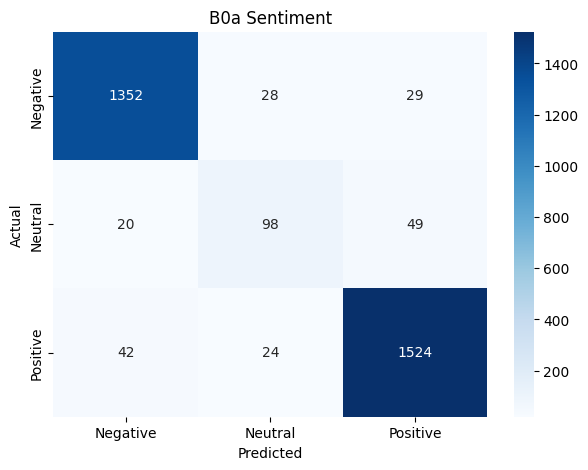


B0b: Topic Baseline


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.6830 | Val Loss: 0.2445 | Train F1: 0.4442 | Val F1: 0.7895
New best (Val F1: 0.7895)
Epoch 02 | Train Loss: 0.2521 | Val Loss: 0.2034 | Train F1: 0.8102 | Val F1: 0.8481
New best (Val F1: 0.8481)
Epoch 03 | Train Loss: 0.1936 | Val Loss: 0.2143 | Train F1: 0.8637 | Val F1: 0.8198
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.1318 | Val Loss: 0.2082 | Train F1: 0.9085 | Val F1: 0.8642
New best (Val F1: 0.8642)
Epoch 05 | Train Loss: 0.0957 | Val Loss: 0.2321 | Train F1: 0.9338 | Val F1: 0.8598
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0645 | Val Loss: 0.2845 | Train F1: 0.9582 | Val F1: 0.8586
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0503 | Val Loss: 0.3127 | Train F1: 0.9691 | Val F1: 0.8533
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation topic Macro F1: 0.8642


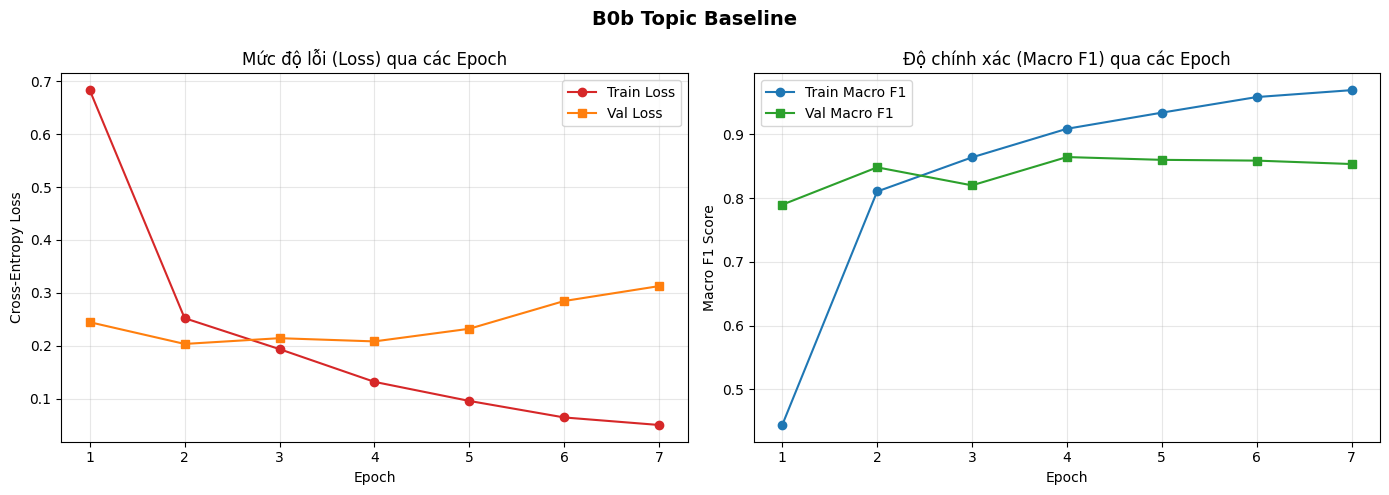


Chẩn đoán validation === B0b Single Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9762    0.9567    0.9664      1156
    Training     0.8376    0.9100    0.8723       289
    Facility     0.9067    0.9444    0.9252        72
      Others     0.7213    0.6667    0.6929        66

    accuracy                         0.9356      1583
   macro avg     0.8604    0.8695    0.8642      1583
weighted avg     0.9371    0.9356    0.9359      1583


=== B0B TOPIC ===
                  precision    recall  f1-score   support

        Lecturer     0.9489    0.9328    0.9408      2290
Training Program     0.7207    0.8392    0.7754       572
        Facility     0.9200    0.9517    0.9356       145
          Others     0.7071    0.4403    0.5426       159

        accuracy                         0.8920      3166
       macro avg     0.8242    0.7910    0.7986      3166
    weighted avg     0.8942    0.8920    0.8907      3166



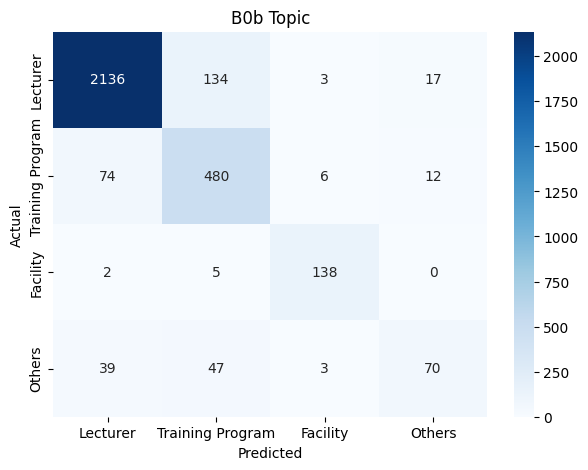

In [10]:
class BaselineModel(nn.Module):
    is_mtl = False
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

def train_single_task(model, train_loader, val_loader, loss_fn, task, model_name="b0", patience=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_ENCODER, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: HUẤN LUYỆN (TRAINING)
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        
        for batch in train_loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            targets = batch[task].to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss = loss_fn(logits, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            train_preds.extend(logits.argmax(-1).cpu().tolist())
            train_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Train
        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")

        # PHA 2: KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets = batch[task].to(DEVICE) # <-- Cần lấy targets để tính val_loss
                
                logits = model(ids, mask)
                loss = loss_fn(logits, targets)
                
                val_loss += loss.item()
                val_preds.extend(logits.argmax(-1).cpu().tolist())
                val_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Validation
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        
        # PHA 3: LƯU LỊCH SỬ VÀ IN KẾT QUẢ
        history.append({
            "epoch": epoch, 
            "train_loss": train_loss, "val_loss": val_loss,
            # "train_acc": train_acc, "val_acc": val_acc,
            "train_f1": train_f1, "val_f1": val_f1
        })
        
        # Format chuỗi in ra y hệt yêu cầu của bạn
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

        # Early Stopping dựa trên Val F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Val F1: {best_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    # Load lại weights tốt nhất trước khi trả về
    model.load_state_dict(best_state)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest validation {task} Macro F1: {best_f1:.4f}")
    
    return model, pd.DataFrame(history)
       

# CHẠY THỰC NGHIỆM B0
# ── B0a: SENTIMENT ──
print("\nB0a: Sentiment Baseline")
model_b0a = BaselineModel(num_classes=NUM_SENTIMENT)
loss_fn_s = nn.CrossEntropyLoss() 

model_b0a, history_b0a = train_single_task(model_b0a, train_loader, val_loader, 
                                           loss_fn_s, task="sentiment", model_name="b0a")
plot_training_history(history_b0a, title="B0a Sentiment Training")
diagnose_validation_single_task(model_b0a, val_loader, "B0a Single Sentiment", task="sentiment")
b0a_report = evaluate_and_plot(model_b0a, test_loader, "sentiment", 
                               ["Negative", "Neutral", "Positive"], "B0a Sentiment")


# ── B0b: TOPIC ──
print("\nB0b: Topic Baseline")
# Khai báo model topic (dùng lại BaselineModel nhưng đổi số lớp)
model_b0b = BaselineModel(num_classes=NUM_TOPIC) 
loss_fn_t = nn.CrossEntropyLoss()

model_b0b, history_b0b = train_single_task(model_b0b, train_loader, val_loader, 
                                           loss_fn_t, task="topic", model_name="b0b")
plot_training_history(history_b0b, title="B0b Topic Baseline")
# Gọi hàm chẩn đoán
diagnose_validation_single_task(model_b0b, val_loader, "B0b Single Topic", task="topic")
b0b_report = evaluate_and_plot(model_b0b, test_loader, "topic", 
                               ["Lecturer", "Training Program", "Facility", "Others"], "B0b Topic")

In [ ]:
# MTL Hard Sharing 
class MTLHardSharing(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

# MTL Cross-Task Attention 
class CrossTaskAttention(nn.Module):
    def __init__(self, hidden_size, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn_s2t = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_t2s = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_s   = nn.LayerNorm(hidden_size)
        self.norm_t   = nn.LayerNorm(hidden_size)

    def forward(self, sent_repr, topic_repr):
        s_refined, _ = self.attn_s2t(sent_repr.unsqueeze(1), topic_repr.unsqueeze(1), topic_repr.unsqueeze(1))
        t_refined, _ = self.attn_t2s(topic_repr.unsqueeze(1), sent_repr.unsqueeze(1), sent_repr.unsqueeze(1))
        s_out = self.norm_s(sent_repr + s_refined.squeeze(1))
        t_out = self.norm_t(topic_repr + t_refined.squeeze(1))
        return s_out, t_out

class MTLCrossTask(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.1, head_dropout=0.1): # Thêm tham số head_dropout
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        self.sent_proj  = nn.Linear(hidden, hidden)
        self.topic_proj = nn.Linear(hidden, hidden)
        self.cross_attn = CrossTaskAttention(hidden, num_heads=4, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.head_dropout = nn.Dropout(head_dropout) # Dropout tăng cường trước classification

        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [B, H]

        s_repr = self.dropout(torch.relu(self.sent_proj(cls)))
        t_repr = self.dropout(torch.relu(self.topic_proj(cls)))

        s_refined, t_refined = self.cross_attn(s_repr, t_repr)
        
        # Áp dụng head_dropout trước khi chẻ nhánh
        return self.sent_head(self.head_dropout(s_refined)), self.topic_head(self.head_dropout(t_refined))

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

def train_mtl(model, train_loader, val_loader, loss_fn_sent, loss_fn_topic, model_name="mtl", patience=PATIENCE):
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: HUẤN LUYỆN (TRAINING)
        model.train()
        train_loss = 0
        train_preds_s, train_targets_s = [], []
        train_preds_t, train_targets_t = [], []
        
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            optimizer.zero_grad()
            logits_s, logits_t = model(ids, mask)
            
            # Tính loss cho từng task và cộng gộp (Lambda mặc định là 1.0)
            loss_s = loss_fn_sent(logits_s, targets_s)
            loss_t = loss_fn_topic(logits_t, targets_t)
            loss = loss_s + loss_t
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            train_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
            train_targets_s.extend(targets_s.cpu().tolist())
            train_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
            train_targets_t.extend(targets_t.cpu().tolist())

        train_loss = train_loss / len(train_loader)

        # PHA 2: KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s = [], []
        val_preds_t, val_targets_t = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                logits_s, logits_t = model(ids, mask)
                
                loss_s = loss_fn_sent(logits_s, targets_s)
                loss_t = loss_fn_topic(logits_t, targets_t)
                loss = loss_s + loss_t
                
                val_loss += loss.item()
                val_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        
        # Tính F1 trên Validation
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        
        # CHỈ SỐ QUYẾT ĐỊNH (Early Stopping dựa trên trung bình cộng 2 task)
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        # In thêm Recall của thiểu số theo epoch để theo dõi
        rep_s = classification_report(
            val_targets_s, val_preds_s,
            target_names=SENT_NAMES,
            output_dict=True,
            zero_division=0,
        )
        rep_t = classification_report(
            val_targets_t, val_preds_t,
            target_names=TOPIC_NAMES,
            output_dict=True,
            zero_division=0,
        )
        neutral_rec = rep_s["Neutral"]["recall"]
        others_rec  = rep_t["Others"]["recall"]
        
        # PHA 3: LƯU LỊCH SỬ VÀ IN KẾT QUẢ
        history.append({
            "epoch": epoch, 
            "train_loss": train_loss, 
            "val_loss": val_loss,
            "sent_macro_f1": val_f1_s,  # Để hàm vẽ plot đọc được
            "topic_macro_f1": val_f1_t,  # Để hàm vẽ plot đọc được
            "neutral_recall": neutral_rec,
            "others_recall":  others_rec,
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Sent F1: {val_f1_s:.4f} | Val Topic F1: {val_f1_t:.4f} | Avg Val F1: {val_avg_f1:.4f} "
              f"| (Neutral Recall: {neutral_rec:.4f}, Others Recall: {others_rec:.4f})")

        # Early Stopping
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Avg Val F1: {best_avg_f1:.4f})")
        else:
            no_improve += 1
            print(f"  --> Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    # Trả về mô hình có weights của Epoch tốt nhất
    model.load_state_dict(best_state)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest validation Avg Macro F1: {best_avg_f1:.4f}")
    
    return model, pd.DataFrame(history), best_avg_f1
    
def plot_mtl_history(history_df, title="MTL Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục Loss (Vẽ cả Train Loss và Val Loss)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Trục F1 (vẽ 2 đường cho 2 task trên tập Validation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Macro F1', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['sent_macro_f1'], label='Val Sentiment F1', color='tab:blue', marker='o')
    ax2.plot(history_df['epoch'], history_df['topic_macro_f1'], label='Val Topic F1', color='tab:green', marker='^')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title, fontweight='bold')
    fig.tight_layout()
    
    # Gộp legend của cả 2 trục cho gọn
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    

def evaluate_and_plot_mtl(model, loader, title_prefix="B1"):
    model.eval()
    s_preds, s_labels = [], []
    t_preds, t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Khác biệt là ở đây: lấy ra 2 logits
            s_logit, t_logit = model(ids, mask)
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    # --- IN REPORT ---
    print(f"\n=== {title_prefix}: SENTIMENT REPORT ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    print(classification_report(s_labels, s_preds, target_names=sent_names, digits=4))

    print(f"\n=== {title_prefix}: TOPIC REPORT ===")
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    print(classification_report(t_labels, t_preds, target_names=topic_names, digits=4))

    # --- VẼ CONFUSION MATRIX (2 HÌNH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(s_labels, s_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment CM ({title_prefix})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(t_labels, t_preds)
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic CM ({title_prefix})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()
    
    # Trả về kết quả để lưu vào bảng tổng kết
    return {
        "sent_macro_f1":  f1_score(s_labels, s_preds, average="macro"),
        "topic_macro_f1": f1_score(t_labels, t_preds, average="macro"),
        "sent_report":    classification_report(s_labels, s_preds, target_names=sent_names, digits=4, output_dict=True),
        "topic_report":   classification_report(t_labels, t_preds, target_names=topic_names, digits=4, output_dict=True),
    }

In [ ]:
def get_predictions(model, loader):
    model.eval()
    s_preds, t_preds = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            out = model(ids, mask)
            s_logit = out[0] if getattr(model, 'is_mtl', False) else out
            t_logit = out[1] if getattr(model, 'is_mtl', False) else out
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
    return s_preds, t_preds
    
def extract_errors_and_evaluate_train(model, train_df, val_df,val_loader, model_name="B1"):
    """
    1. In báo cáo classification_report trên tập Train
    2. Vẽ Confusion Matrix trực quan cho tập Train
    3. Trích xuất các mẫu bị đoán sai trên cả Train và Val (Dùng câu gốc chưa segment để dễ đọc)
    """
    print(f"\n" + "="*50)
    print(f"PHÂN TÍCH LỖI & TRÍCH XUẤT DỮ LIỆU NHIỄU ({model_name})")
    print("="*50)
    
    # 1. Tạo loader không xáo trộn (shuffle=False) để dự đoán không bị lệch hàng
    train_eval_loader = make_loader(train_df, shuffle=False)
    # global val_loader 
    
    # 2. Lấy dự đoán
    train_s_preds, train_t_preds = get_predictions(model, train_eval_loader)
    val_s_preds, val_t_preds = get_predictions(model, val_loader)
    
    # 3. Gắn kết quả vào DataFrame
    train_copy = train_df.copy()
    train_copy['pred_sentiment'] = train_s_preds
    train_copy['pred_topic'] = train_t_preds
    train_copy['split'] = 'train'
    
    val_copy = val_df.copy()
    val_copy['pred_sentiment'] = val_s_preds
    val_copy['pred_topic'] = val_t_preds
    val_copy['split'] = 'val'
    
    # IN REPORT & VẼ CM CHO TẬP TRAIN
    print(f"\n=== {model_name}: BÁO CÁO HIỆU SUẤT TRÊN TẬP TRAIN ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    
    print("SENTIMENT:")
    print(classification_report(train_copy['sentiment'], train_copy['pred_sentiment'], 
                                target_names=sent_names, digits=4))
    print("TOPIC:")
    print(classification_report(train_copy['topic'], train_copy['pred_topic'], 
                                target_names=topic_names, digits=4))
    
    # Vẽ Confusion Matrix cho Train
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(train_copy['sentiment'], train_copy['pred_sentiment'])
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment Train CM ({model_name})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(train_copy['topic'], train_copy['pred_topic'])
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic Train CM ({model_name})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    # PHẦN TRÍCH XUẤT LỖI
    combined_df = pd.concat([train_copy, val_copy], ignore_index=True)
    
    # Lọc câu sai (sai Sent HOẶC sai Topic)
    error_df = combined_df[(combined_df['sentiment'] != combined_df['pred_sentiment']) | 
                           (combined_df['topic'] != combined_df['pred_topic'])].copy()
    
    print(f"\nTổng số câu bị mô hình {model_name} đoán sai (Train + Val): {len(error_df)} câu")
    
    # Map nhãn sang chữ
    s_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    t_map = {0: 'Lecturer', 1: 'Training Program', 2: 'Facility', 3: 'Others'}
    
    error_df['Actual_Sentiment'] = error_df['sentiment'].map(s_map)
    error_df['Pred_Sentiment'] = error_df['pred_sentiment'].map(s_map)
    error_df['Actual_Topic'] = error_df['topic'].map(t_map)
    error_df['Pred_Topic'] = error_df['pred_topic'].map(t_map)
    
    # Cột trống cho LLM và Reviewer
    error_df['LLM_Sentiment'] = ""
    error_df['LLM_Topic'] = ""
    error_df['LLM_Reasoning'] = ""
    error_df['Human_Final_Sentiment'] = ""
    error_df['Human_Final_Topic'] = ""
    
    # CHÚ Ý Ở ĐÂY: Dùng 'sentence' thay vì 'sentence_seg' cho dễ đọc!
    cols_to_export = [
        'split', 'sentence', 
        'Actual_Sentiment', 'Pred_Sentiment', 'LLM_Sentiment', 'Human_Final_Sentiment',
        'Actual_Topic', 'Pred_Topic', 'LLM_Topic', 'Human_Final_Topic',
        'LLM_Reasoning'
    ]
    
    # Xử lý trường hợp nếu dataframe của bạn không có cột 'sentence' (chỉ có 'sentence_seg')
    if 'sentence' not in error_df.columns and 'sentence_seg' in error_df.columns:
        # Tự động loại bỏ dấu gạch dưới để khôi phục lại câu gốc
        error_df['sentence'] = error_df['sentence_seg'].str.replace('_', ' ')
    
    output_file = f"Suspected_Errors_{model_name}.xlsx"
    error_df[cols_to_export].to_excel(output_file, index=False)
    print(f"-> Đã xuất danh sách câu lỗi ra file: {output_file}")
    
    return error_df


B1: MTL Hard Sharing + Standard CE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.3288 | Val Loss: 0.5256 | Val Sent F1: 0.6373 | Val Topic F1: 0.7055 | Avg Val F1: 0.6714 | (Neutral Recall: 0.0000, Others Recall: 0.1061)
New best (Avg Val F1: 0.6714)
Epoch 02 | Train Loss: 0.4644 | Val Loss: 0.3619 | Val Sent F1: 0.8154 | Val Topic F1: 0.8423 | Avg Val F1: 0.8288 | (Neutral Recall: 0.3614, Others Recall: 0.4848)
New best (Avg Val F1: 0.8288)
Epoch 03 | Train Loss: 0.3383 | Val Loss: 0.3111 | Val Sent F1: 0.8444 | Val Topic F1: 0.8800 | Avg Val F1: 0.8622 | (Neutral Recall: 0.4217, Others Recall: 0.6970)
New best (Avg Val F1: 0.8622)
Epoch 04 | Train Loss: 0.2455 | Val Loss: 0.3174 | Val Sent F1: 0.8687 | Val Topic F1: 0.8720 | Avg Val F1: 0.8703 | (Neutral Recall: 0.5181, Others Recall: 0.7273)
New best (Avg Val F1: 0.8703)
Epoch 05 | Train Loss: 0.1763 | Val Loss: 0.3509 | Val Sent F1: 0.8668 | Val Topic F1: 0.8703 | Avg Val F1: 0.8685 | (Neutral Recall: 0.5181, Others Recall: 0.7424)
  --> Không cải thiện 1/5
Epoch 06 | Train Loss: 0.1297

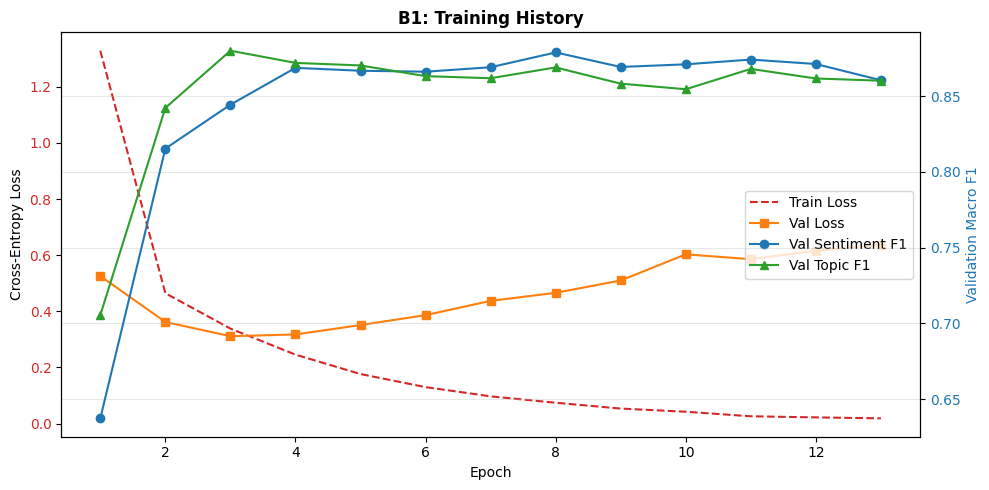


Chấn đoán trên validation === B1_Hard_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9634    0.9842    0.9737       695
     Neutral     0.7812    0.6024    0.6803        83
    Positive     0.9802    0.9851    0.9827       805

    accuracy                         0.9646      1583
   macro avg     0.9083    0.8572    0.8789      1583
weighted avg     0.9624    0.9646    0.9629      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9596    0.9663    0.9629      1156
    Training     0.8741    0.8166    0.8444       289
    Facility     0.9324    0.9583    0.9452        72
      Others     0.6800    0.7727    0.7234        66

    accuracy                         0.9305      1583
   macro avg     0.8615    0.8785    0.8690      1583
weighted avg     0.9311    0.9305    0.9305      1583


=== B1 MTL Hard Sharing: SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0

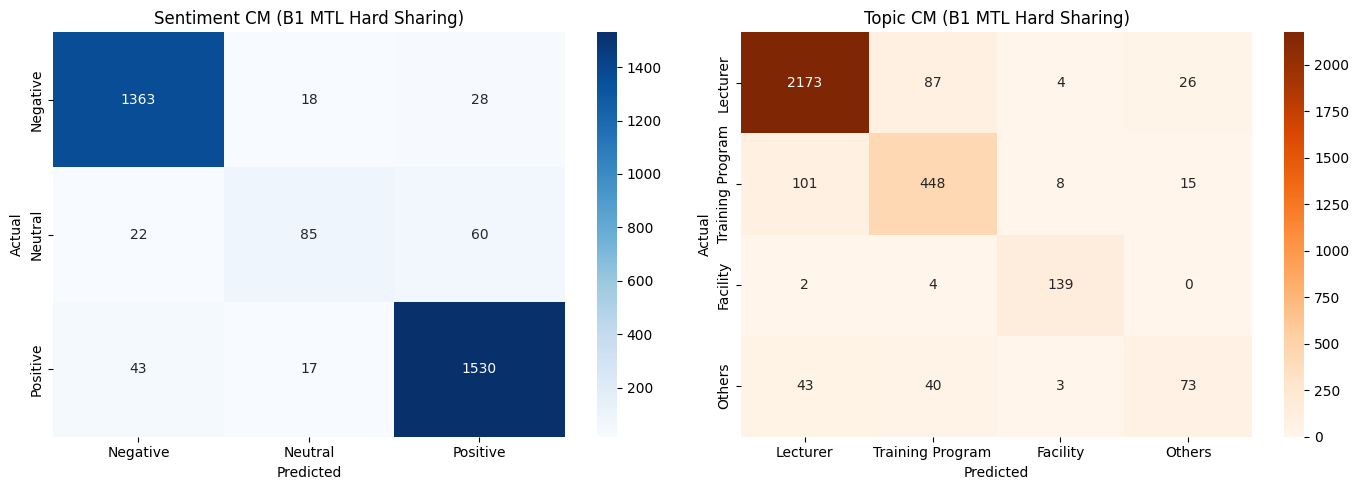


PHÂN TÍCH LỖI & TRÍCH XUẤT DỮ LIỆU NHIỄU (B1)

=== B1: BÁO CÁO HIỆU SUẤT TRÊN TẬP TRAIN ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9981    0.9989    0.9985      5312
     Neutral     0.9801    0.9569    0.9684       464
    Positive     0.9981    0.9993    0.9987      5650

    accuracy                         0.9974     11426
   macro avg     0.9921    0.9850    0.9885     11426
weighted avg     0.9974    0.9974    0.9974     11426

TOPIC:
                  precision    recall  f1-score   support

        Lecturer     0.9978    0.9987    0.9982      8212
Training Program     0.9969    0.9920    0.9944      2256
        Facility     0.9902    1.0000    0.9951       506
          Others     0.9845    0.9823    0.9834       452

        accuracy                         0.9968     11426
       macro avg     0.9923    0.9932    0.9928     11426
    weighted avg     0.9968    0.9968    0.9968     11426



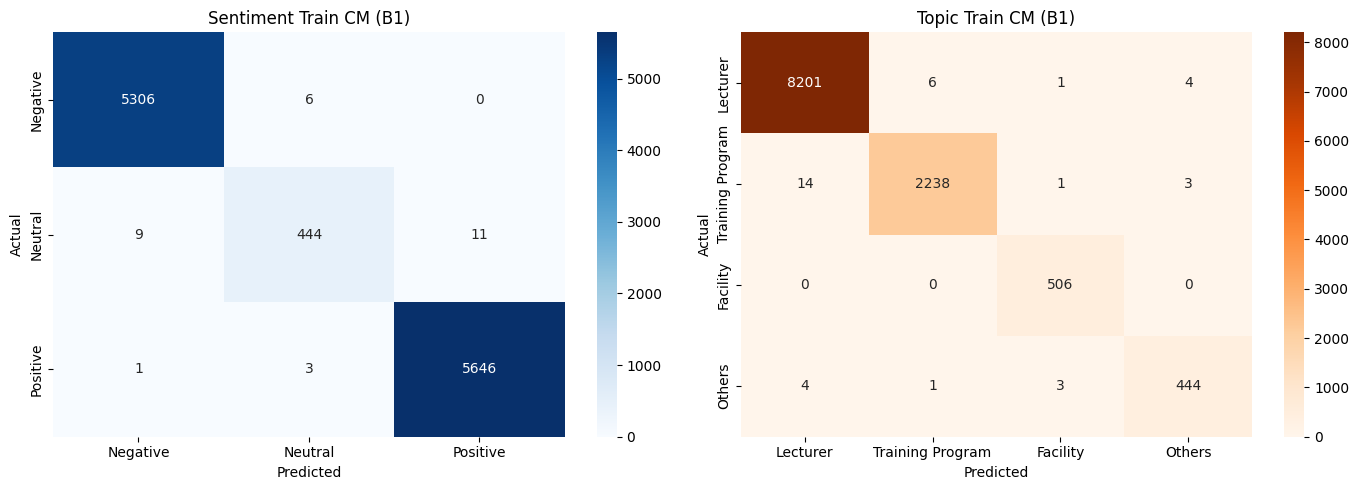


Tổng số câu bị mô hình B1 đoán sai (Train + Val): 216 câu
-> Đã xuất danh sách câu lỗi ra file: Suspected_Errors_B1.xlsx

B2a: MTL Cross-Task Attention + Standard CE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.0398 | Val Loss: 0.4353 | Val Sent F1: 0.7385 | Val Topic F1: 0.8150 | Avg Val F1: 0.7767 | (Neutral Recall: 0.1928, Others Recall: 0.4545)
New best (Avg Val F1: 0.7767)
Epoch 02 | Train Loss: 0.4560 | Val Loss: 0.3974 | Val Sent F1: 0.8243 | Val Topic F1: 0.8151 | Avg Val F1: 0.8197 | (Neutral Recall: 0.3614, Others Recall: 0.4394)
New best (Avg Val F1: 0.8197)
Epoch 03 | Train Loss: 0.3438 | Val Loss: 0.3610 | Val Sent F1: 0.8524 | Val Topic F1: 0.8571 | Avg Val F1: 0.8548 | (Neutral Recall: 0.4699, Others Recall: 0.6667)
New best (Avg Val F1: 0.8548)
Epoch 04 | Train Loss: 0.2541 | Val Loss: 0.3806 | Val Sent F1: 0.8236 | Val Topic F1: 0.8662 | Avg Val F1: 0.8449 | (Neutral Recall: 0.3614, Others Recall: 0.6970)
  --> Không cải thiện 1/5
Epoch 05 | Train Loss: 0.1797 | Val Loss: 0.4038 | Val Sent F1: 0.8467 | Val Topic F1: 0.8611 | Avg Val F1: 0.8539 | (Neutral Recall: 0.4458, Others Recall: 0.6364)
  --> Không cải thiện 2/5
Epoch 06 | Train Loss: 0.1234 | V

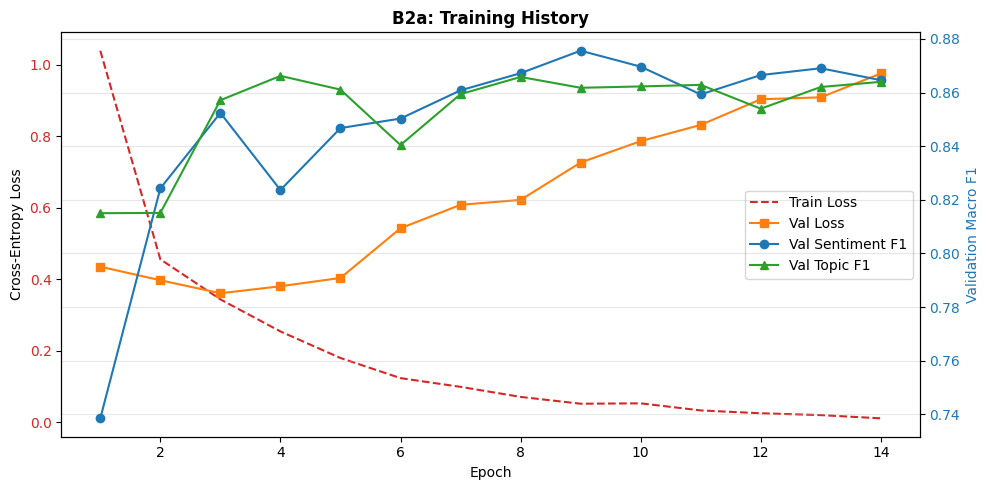


Chấn đoán trên validation === B2a_Cross_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9490    0.9899    0.9690       695
     Neutral     0.7903    0.5904    0.6759        83
    Positive     0.9874    0.9764    0.9819       805

    accuracy                         0.9621      1583
   macro avg     0.9089    0.8522    0.8756      1583
weighted avg     0.9602    0.9621    0.9602      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9602    0.9593    0.9598      1156
    Training     0.8505    0.8858    0.8678       289
    Facility     0.9583    0.9583    0.9583        72
      Others     0.7273    0.6061    0.6612        66

    accuracy                         0.9311      1583
   macro avg     0.8741    0.8524    0.8618      1583
weighted avg     0.9304    0.9311    0.9305      1583


=== B2a_MTL_CrossTask_CE: SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative   

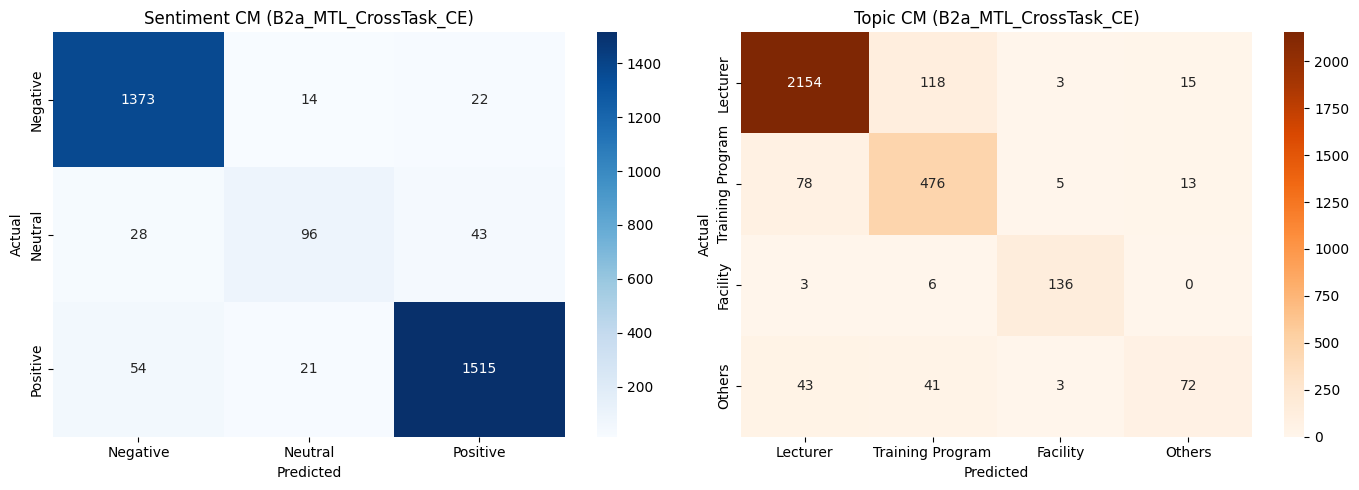


PHÂN TÍCH LỖI & TRÍCH XUẤT DỮ LIỆU NHIỄU (B2a)

=== B2a: BÁO CÁO HIỆU SUẤT TRÊN TẬP TRAIN ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9985    1.0000    0.9992      5312
     Neutral     0.9809    0.9957    0.9882       464
    Positive     1.0000    0.9973    0.9987      5650

    accuracy                         0.9985     11426
   macro avg     0.9931    0.9977    0.9954     11426
weighted avg     0.9985    0.9985    0.9985     11426

TOPIC:
                  precision    recall  f1-score   support

        Lecturer     0.9987    0.9976    0.9981      8212
Training Program     0.9916    0.9965    0.9940      2256
        Facility     0.9980    1.0000    0.9990       506
          Others     0.9955    0.9889    0.9922       452

        accuracy                         0.9971     11426
       macro avg     0.9960    0.9957    0.9958     11426
    weighted avg     0.9971    0.9971    0.9971     11426



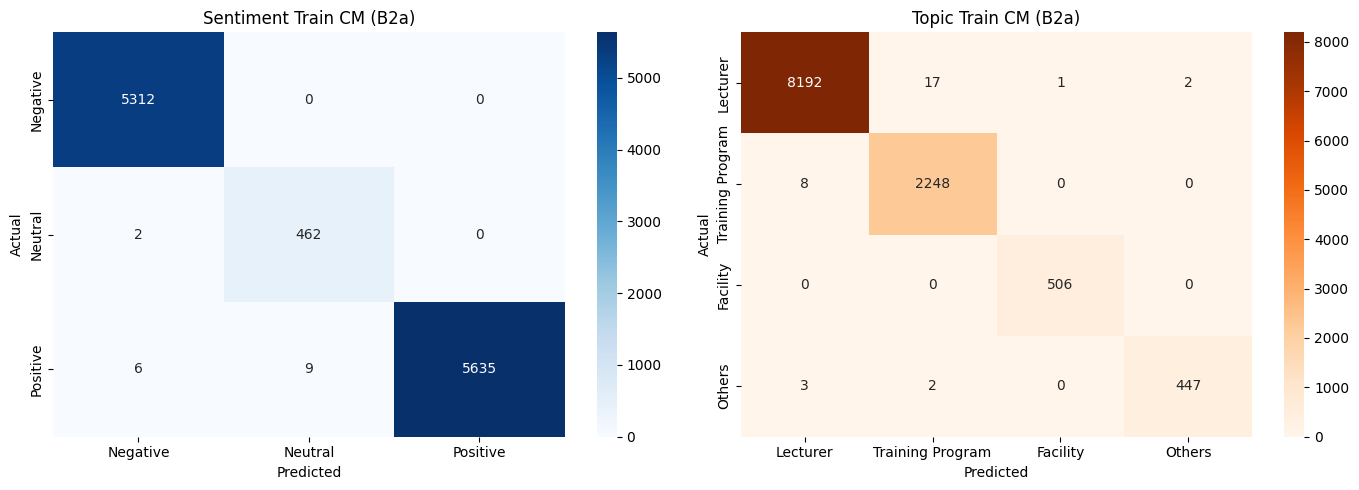


Tổng số câu bị mô hình B2a đoán sai (Train + Val): 203 câu
-> Đã xuất danh sách câu lỗi ra file: Suspected_Errors_B2a.xlsx

B2b: MTL Cross-Task + Label Smoothing (0.1) + Head Dropout (0.3)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.4535 | Val Loss: 0.9684 | Val Sent F1: 0.7471 | Val Topic F1: 0.8351 | Avg Val F1: 0.7911 | (Neutral Recall: 0.1928, Others Recall: 0.5606)
New best (Avg Val F1: 0.7911)
Epoch 02 | Train Loss: 0.9731 | Val Loss: 0.8720 | Val Sent F1: 0.8534 | Val Topic F1: 0.8663 | Avg Val F1: 0.8599 | (Neutral Recall: 0.4819, Others Recall: 0.5606)
New best (Avg Val F1: 0.8599)
Epoch 03 | Train Loss: 0.8874 | Val Loss: 0.8829 | Val Sent F1: 0.8514 | Val Topic F1: 0.8523 | Avg Val F1: 0.8519 | (Neutral Recall: 0.4819, Others Recall: 0.5455)
  --> Không cải thiện 1/5
Epoch 04 | Train Loss: 0.8175 | Val Loss: 0.8710 | Val Sent F1: 0.8229 | Val Topic F1: 0.8707 | Avg Val F1: 0.8468 | (Neutral Recall: 0.3735, Others Recall: 0.6818)
  --> Không cải thiện 2/5
Epoch 05 | Train Loss: 0.7721 | Val Loss: 0.8621 | Val Sent F1: 0.8716 | Val Topic F1: 0.8710 | Avg Val F1: 0.8713 | (Neutral Recall: 0.5422, Others Recall: 0.6818)
New best (Avg Val F1: 0.8713)
Epoch 06 | Train Loss: 0.7350 | V

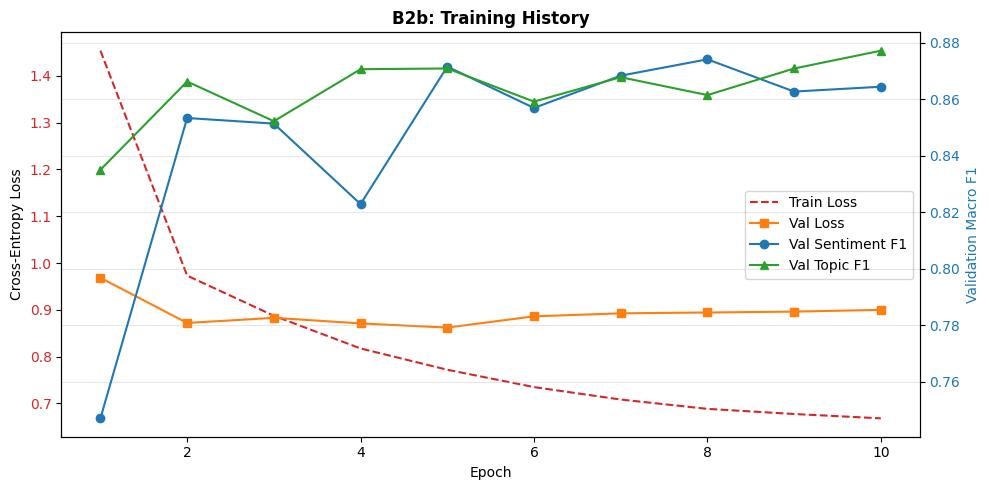


Chấn đoán trên validation === B2b_Cross_Smooth ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9633    0.9813    0.9722       695
     Neutral     0.8491    0.5422    0.6618        83
    Positive     0.9708    0.9913    0.9809       805

    accuracy                         0.9634      1583
   macro avg     0.9277    0.8383    0.8716      1583
weighted avg     0.9611    0.9634    0.9604      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9738    0.9654    0.9696      1156
    Training     0.8595    0.8893    0.8741       289
    Facility     0.9583    0.9583    0.9583        72
      Others     0.6818    0.6818    0.6818        66

    accuracy                         0.9394      1583
   macro avg     0.8684    0.8737    0.8710      1583
weighted avg     0.9401    0.9394    0.9397      1583


=== B2b_MTL_CrossTask_Smooth: SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Neg

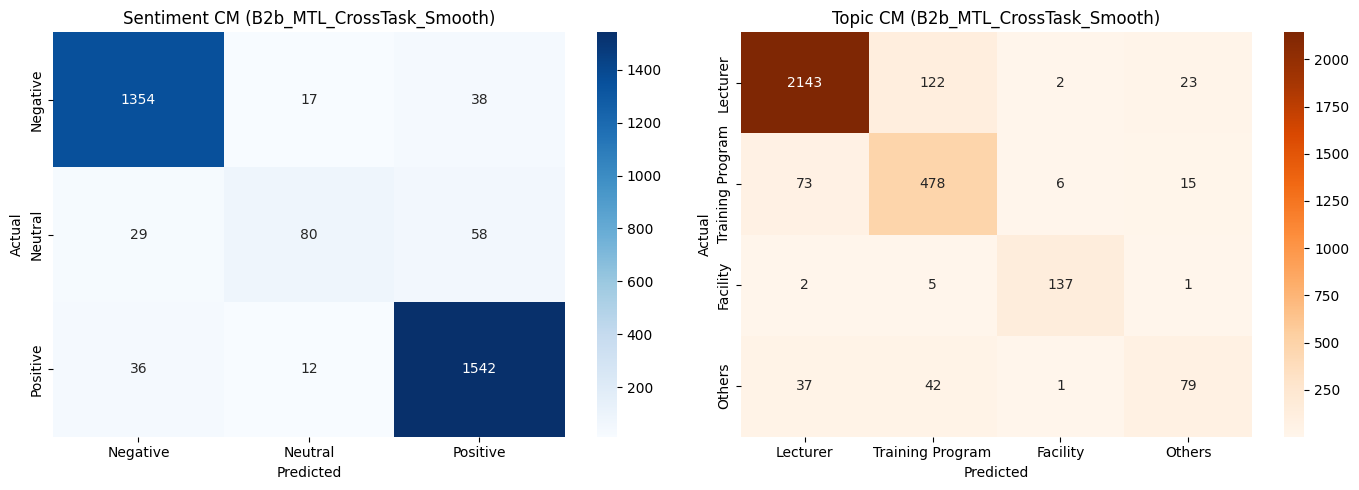


PHÂN TÍCH LỖI & TRÍCH XUẤT DỮ LIỆU NHIỄU (B2b)

=== B2b: BÁO CÁO HIỆU SUẤT TRÊN TẬP TRAIN ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9929    0.9944    0.9936      5312
     Neutral     0.9704    0.8470    0.9045       464
    Positive     0.9891    0.9981    0.9936      5650

    accuracy                         0.9902     11426
   macro avg     0.9841    0.9465    0.9639     11426
weighted avg     0.9901    0.9902    0.9900     11426

TOPIC:
                  precision    recall  f1-score   support

        Lecturer     0.9916    0.9921    0.9918      8212
Training Program     0.9695    0.9707    0.9701      2256
        Facility     0.9902    0.9980    0.9941       506
          Others     0.9297    0.9071    0.9183       452

        accuracy                         0.9848     11426
       macro avg     0.9702    0.9670    0.9686     11426
    weighted avg     0.9847    0.9848    0.9847     11426



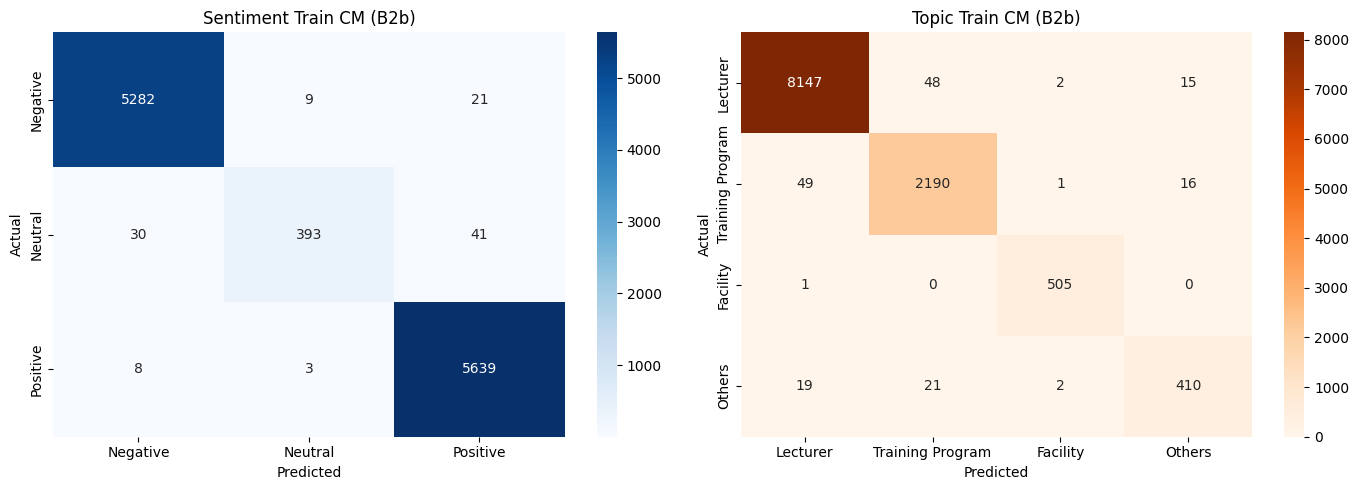


Tổng số câu bị mô hình B2b đoán sai (Train + Val): 421 câu
-> Đã xuất danh sách câu lỗi ra file: Suspected_Errors_B2b.xlsx


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0803 | Val Loss: 0.0284 | Val Sent F1: 0.7243 | Val Topic F1: 0.7457 | Avg Val F1: 0.7350 | (Neutral Recall: 0.8313, Others Recall: 0.9091)
New best (Avg Val F1: 0.7350)
Epoch 02 | Train Loss: 0.0332 | Val Loss: 0.0448 | Val Sent F1: 0.8259 | Val Topic F1: 0.8105 | Avg Val F1: 0.8182 | (Neutral Recall: 0.4699, Others Recall: 0.8182)
New best (Avg Val F1: 0.8182)
Epoch 03 | Train Loss: 0.0221 | Val Loss: 0.0333 | Val Sent F1: 0.8494 | Val Topic F1: 0.8567 | Avg Val F1: 0.8531 | (Neutral Recall: 0.5904, Others Recall: 0.7879)
New best (Avg Val F1: 0.8531)
Epoch 04 | Train Loss: 0.0133 | Val Loss: 0.0587 | Val Sent F1: 0.8623 | Val Topic F1: 0.7990 | Avg Val F1: 0.8306 | (Neutral Recall: 0.5181, Others Recall: 0.8788)
  --> Không cải thiện 1/5
Epoch 05 | Train Loss: 0.0094 | Val Loss: 0.0376 | Val Sent F1: 0.8498 | Val Topic F1: 0.8305 | Avg Val F1: 0.8401 | (Neutral Recall: 0.6386, Others Recall: 0.8636)
  --> Không cải thiện 2/5
Epoch 06 | Train Loss: 0.0071 | V

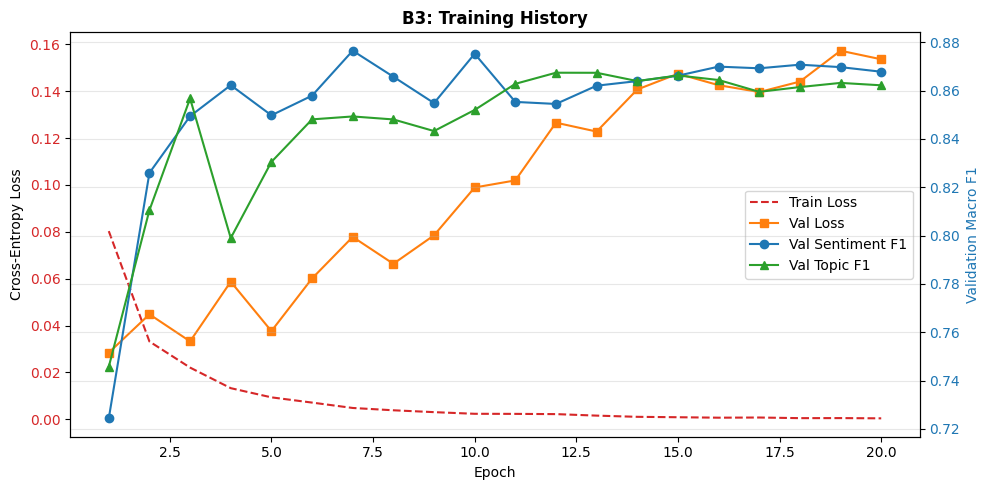


Chấn đoán trên validation === B3_Cross_FocalLoss ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9633    0.9813    0.9722       695
     Neutral     0.7833    0.5663    0.6573        83
    Positive     0.9742    0.9863    0.9802       805

    accuracy                         0.9621      1583
   macro avg     0.9069    0.8446    0.8699      1583
weighted avg     0.9594    0.9621    0.9598      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9689    0.9446    0.9566      1156
    Training     0.8591    0.8651    0.8621       289
    Facility     0.9722    0.9722    0.9722        72
      Others     0.5699    0.8030    0.6667        66

    accuracy                         0.9255      1583
   macro avg     0.8425    0.8962    0.8644      1583
weighted avg     0.9324    0.9255    0.9280      1583


=== B3_Cross_FocalLoss: SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negativ

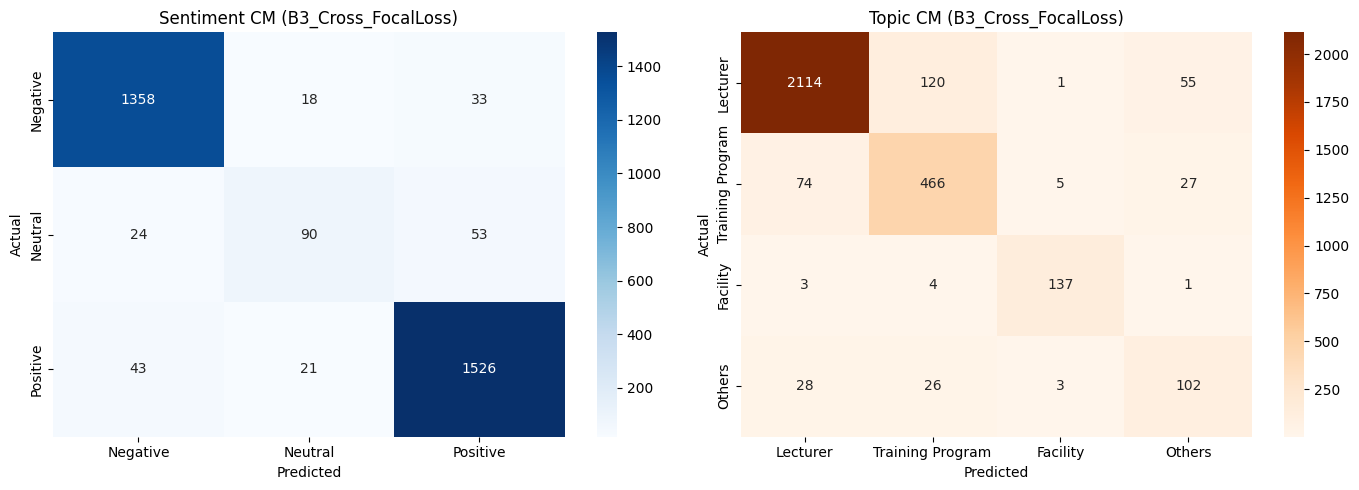


PHÂN TÍCH LỖI & TRÍCH XUẤT DỮ LIỆU NHIỄU (B3)

=== B3: BÁO CÁO HIỆU SUẤT TRÊN TẬP TRAIN ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000      5312
     Neutral     0.9978    1.0000    0.9989       464
    Positive     1.0000    0.9998    0.9999      5650

    accuracy                         0.9999     11426
   macro avg     0.9993    0.9999    0.9996     11426
weighted avg     0.9999    0.9999    0.9999     11426

TOPIC:
                  precision    recall  f1-score   support

        Lecturer     0.9968    0.9823    0.9895      8212
Training Program     0.9579    0.9880    0.9727      2256
        Facility     1.0000    1.0000    1.0000       506
          Others     0.9040    1.0000    0.9496       452

        accuracy                         0.9849     11426
       macro avg     0.9647    0.9926    0.9780     11426
    weighted avg     0.9856    0.9849    0.9851     11426



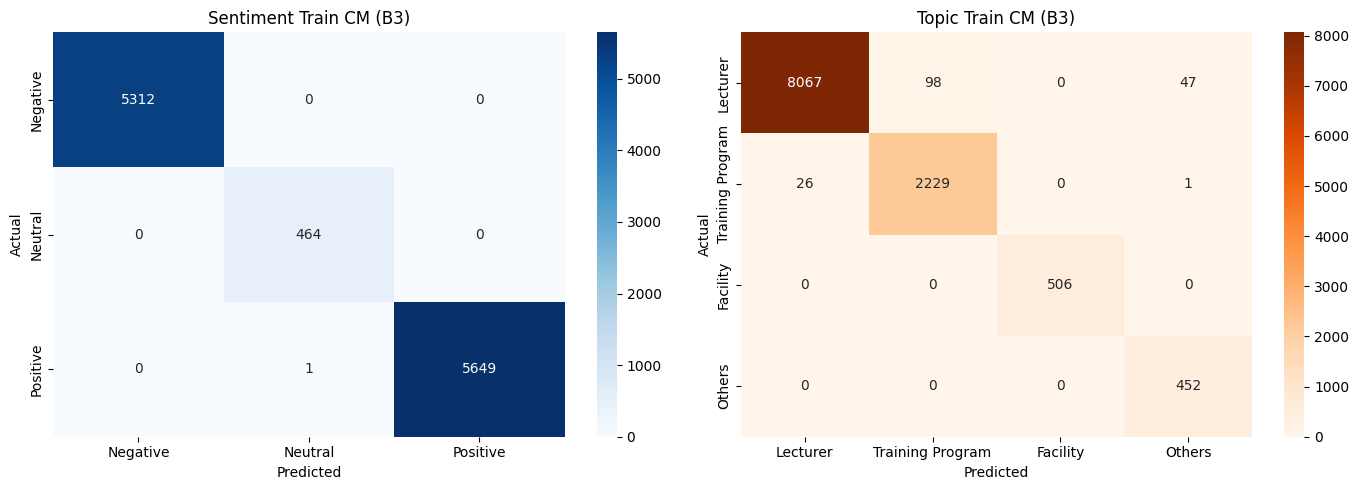


Tổng số câu bị mô hình B3 đoán sai (Train + Val): 336 câu
-> Đã xuất danh sách câu lỗi ra file: Suspected_Errors_B3.xlsx

ABLATION STUDY — TEST SET RESULTS (B1 vs B2)
                          Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                                    
B1_MTL_CE                       0.8161         0.8357      0.9609      0.5923      0.9539          0.7965      0.9429      0.7785       0.9298     0.5348
B2a_MTL_CrossTask_CE            0.8284         0.8530      0.9588      0.6443      0.9558          0.8039      0.9431      0.7848       0.9315     0.5560
B2b_MTL_CrossTask_Smooth        0.8203         0.8309      0.9576      0.5797      0.9554          0.8098      0.9430      0.7842       0.9416     0.5704
B3_Cross_FocalLoss              0.8270         0.8399      0.9

In [ ]:
# 5. CHẠY ABLATION STUDY
results = {}

# Khởi tạo Loss Function cho MTL (CE)
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

# ── B1: MTL Hard Sharing + CE ──
print("\n" + "="*50)
print("B1: MTL Hard Sharing + Standard CE")
print("="*50)
model_b1 = MTLHardSharing()
model_b1, hist_b1, val_f1_b1 = train_mtl(model_b1, train_loader, val_loader, 
                              ce_sent, ce_topic, model_name="B1_Hard_CE")
# 1. Vẽ History
plot_mtl_history(hist_b1, title="B1: Training History")
diagnose_validation(model_b1, val_loader, "B1_Hard_CE")
# 2. In report & Vẽ 2 Confusion Matrix
results["B1_MTL_CE"] = evaluate_and_plot_mtl(model_b1, test_loader, title_prefix="B1 MTL Hard Sharing")
errors_df_b1b = extract_errors_and_evaluate_train(model_b1, train_df, val_df, val_loader, model_name="B1")

# ── B2a: MTL Cross-Task + CE ──
print("\n" + "="*50)
print("B2a: MTL Cross-Task Attention + Standard CE")
print("="*50)
model_b2a = MTLCrossTask(head_dropout=0.1)
model_b2a, hist_b2a, val_f1_b2a = train_mtl(model_b2a, train_loader, val_loader, 
                              ce_sent, ce_topic, model_name="B2a_Cross_CE")
# 1. Vẽ History
plot_mtl_history(hist_b2a, title="B2a: Training History")
diagnose_validation(model_b2a, val_loader, "B2a_Cross_CE")
# 2. In report & Vẽ 2 Confusion Matrix
results["B2a_MTL_CrossTask_CE"] = evaluate_and_plot_mtl(model_b2a, test_loader, title_prefix="B2a_MTL_CrossTask_CE")
errors_df_b2a = extract_errors_and_evaluate_train(model_b2a, train_df, val_df, val_loader, model_name="B2a")


# ── B2b: MTL Cross-Task + Label Smoothing + High Dropout ──
print("\n" + "="*50)
print("B2b: MTL Cross-Task + Label Smoothing (0.1) + Head Dropout (0.3)")
print("="*50)
ce_sent_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)
ce_topic_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)

model_b2b = MTLCrossTask(head_dropout=0.3) # Tăng Dropout
model_b2b, hist_b2b, val_f1_b2b = train_mtl(model_b2b, train_loader, val_loader, ce_sent_smooth, ce_topic_smooth, model_name="B2b_Cross_Smooth")
plot_mtl_history(hist_b2b, title="B2b: Training History")
diagnose_validation(model_b2b, val_loader, "B2b_Cross_Smooth") # Chẩn đoán Val xem Neutral/Facility có khá hơn không
results["B2b_MTL_CrossTask_Smooth"] = evaluate_and_plot_mtl(model_b2b, test_loader, title_prefix="B2b_MTL_CrossTask_Smooth")
errors_df_b2b = extract_errors_and_evaluate_train(model_b2b, train_df, val_df, val_loader, model_name="B2b")

# B3: MTL Cross-Task + Focal Loss
focal_sent_b3  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic_b3 = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

model_b3 = MTLCrossTask(head_dropout=DROPOUT) # Tăng Dropout
model_b3, hist_b3, val_f1_b3 = train_mtl(model_b3, train_loader, val_loader, focal_sent_b3, focal_topic_b3, model_name="B3_Cross_FocalLoss")
plot_mtl_history(hist_b3, title="B3: Training History")
diagnose_validation(model_b3, val_loader, "B3_Cross_FocalLoss") # Chẩn đoán Val xem Neutral/Facility có khá hơn không
results["B3_Cross_FocalLoss"] = evaluate_and_plot_mtl(model_b3, test_loader, title_prefix="B3_Cross_FocalLoss")
errors_df_b3 = extract_errors_and_evaluate_train(model_b3, train_df, val_df, val_loader, model_name="B3")


# 6. IN BẢNG SO SÁNH KẾT QUẢ TEST SET
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

rows = []
for name, res in results.items():
    s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
    t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
    rows.append({
        "Model":            name,
        "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
        "Sent macro-F1":    round(res["sent_macro_f1"], 4),
        "S-Negative":       s_per["Negative"],
        "S-Neutral*":       s_per["Neutral"],      # Lớp thiểu số
        "S-Positive":       s_per["Positive"],
        "Topic macro-F1":   round(res["topic_macro_f1"], 4),
        "T-Lecturer":       t_per["Lecturer"],
        "T-Training":       t_per["Training Program"],
        "T-Facility*":      t_per["Facility"],     # Lớp thiểu số
        "T-Others*":        t_per["Others"],       # Lớp thiểu số
    })

df_results = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — TEST SET RESULTS (B1 vs B2)")
print("=" * 110)
print(df_results.to_string())
print("\n(*) Ghi chú: Các lớp thiểu số có dữ liệu mất cân bằng nghiêm trọng.")

# Ensemble voting để tìm kiếm nhãn nhiễu

In [ ]:
# 7. ENSEMBLE SOFT-VOTING: TÌM KIẾM NHÃN NHIỄU TRÊN TEST SET
import torch.nn.functional as F

print("\n" + "=" * 60)
print("BẮT ĐẦU QUY TRÌNH ENSEMBLE SOFT-VOTING TRÊN TEST SET")
print("=" * 60)

# 1. Gom nhóm mô hình cho từng Task
# B0a chỉ dự đoán Sentiment, B0b chỉ dự đoán Topic
models_sentiment = [model_b0a, model_b1, model_b2a, model_b2b, model_b3]
models_topic     = [model_b0b, model_b1, model_b2a, model_b2b, model_b3]

def get_ensemble_soft_probs(models_s, models_t, loader):
    all_models = list({id(m): m for m in models_s + models_t}.values())
    for m in all_models:
        m.eval()
        m.to(DEVICE)
        
    all_s_probs, all_t_probs = [], []
    all_s_labels, all_t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            
            batch_s_probs = []
            for m in models_s:
                out = m(ids, mask)
                logits_s = out[0] if getattr(m, 'is_mtl', False) else out 
                probs_s = F.softmax(logits_s, dim=-1)
                batch_s_probs.append(probs_s)
                
            avg_s_probs = torch.stack(batch_s_probs).mean(dim=0)
            all_s_probs.extend(avg_s_probs.cpu().numpy())
            all_s_labels.extend(batch["sentiment"].tolist())
            
            batch_t_probs = []
            for m in models_t:
                out = m(ids, mask)
                logits_t = out[1] if getattr(m, 'is_mtl', False) else out
                probs_t = F.softmax(logits_t, dim=-1)
                batch_t_probs.append(probs_t)
                
            avg_t_probs = torch.stack(batch_t_probs).mean(dim=0)
            all_t_probs.extend(avg_t_probs.cpu().numpy())
            all_t_labels.extend(batch["topic"].tolist())
            
    return np.array(all_s_probs), np.array(all_t_probs), np.array(all_s_labels), np.array(all_t_labels)


# 2. Chạy Ensemble Inference
print("Đang chạy dự đoán Ensemble trên Test Set...")
s_probs, t_probs, s_labels, t_labels = get_ensemble_soft_probs(models_sentiment, models_topic, test_loader)

# 3. Thuật toán trích xuất các câu tình nghi (Suspects Filtering)
confidence_threshold = 0.75
suspects = []

# Lấy nhãn dự đoán (argmax) và độ tự tin (max prob)
s_preds = np.argmax(s_probs, axis=1)
s_conf  = np.max(s_probs, axis=1)

t_preds = np.argmax(t_probs, axis=1)
t_conf  = np.max(t_probs, axis=1)

print("\n[PHÂN TÍCH ĐỘ NHẠY CỦA NGƯỠNG CONFIDENCE]")
for threshold in [0.65, 0.70, 0.75, 0.80]:
    n_suspects = sum(
        1 for i in range(len(test_df))
        if (s_preds[i] != s_labels[i] and s_conf[i] >= threshold) or
           (t_preds[i] != t_labels[i] and t_conf[i] >= threshold)
    )
    print(f"Ngưỡng {threshold}: {n_suspects} câu bị đưa vào diện tình nghi")

s_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
t_map = {0: 'Lecturer', 1: 'Training Program', 2: 'Facility', 3: 'Others'}

for i in range(len(test_df)):
    gt_s_str, pred_s_str = s_map[s_labels[i]], s_map[s_preds[i]]
    gt_t_str, pred_t_str = t_map[t_labels[i]], t_map[t_preds[i]]
    
    sentence = test_df.iloc[i]['sentence'] if 'sentence' in test_df.columns else test_df.iloc[i]['sentence_seg'].replace('_', ' ')
    
    is_suspect = False
    error_types = []
    
    if pred_s_str != gt_s_str and s_conf[i] >= confidence_threshold:
        is_suspect = True
        err_tag = "Target_Neutral_Error" if gt_s_str == 'Neutral' else f"General_Sent_Error({gt_s_str}->{pred_s_str})"
        error_types.append(err_tag)
        
    if pred_t_str != gt_t_str and t_conf[i] >= confidence_threshold:
        is_suspect = True
        err_tag = "Target_Others_Error" if gt_t_str == 'Others' else f"General_Topic_Error({gt_t_str}->{pred_t_str})"
        error_types.append(err_tag)
        
    if is_suspect:
        suspects.append({
            "Test_Index": i,
            "Sentence": sentence,
            "Flag_Reason": " & ".join(error_types),
            "GT_Sentiment": gt_s_str, "Pred_Sentiment": pred_s_str, "Ensemble_Sent_Conf": round(s_conf[i], 4),
            "GT_Topic": gt_t_str, "Pred_Topic": pred_t_str, "Ensemble_Topic_Conf": round(t_conf[i], 4),
            "LLM_Review": "", "Human_Final_Decision": ""
        })

# 4. Xuất file báo cáo
df_suspects = pd.DataFrame(suspects)
output_filename = "TestSet_Targeted_Relabel_Suspects.xlsx"

if not df_suspects.empty:
    df_suspects.to_excel(output_filename, index=False)
    print(f"\nĐã tìm thấy {len(df_suspects)} câu tình nghi có nhãn nhiễu.")
    print(f"Danh sách đã được xuất ra file: {output_filename}")
    print("Mời chuyên gia mở file và tiến hành relabel cột 'Human_Final_Decision'.")
else:
    print("\nKhông tìm thấy câu nào thỏa mãn điều kiện tình nghi. Dữ liệu của bạn rất sạch!")


BẮT ĐẦU QUY TRÌNH ENSEMBLE SOFT-VOTING TRÊN TEST SET
Đang chạy dự đoán Ensemble trên Test Set...

[PHÂN TÍCH ĐỘ NHẠY CỦA NGƯỠNG CONFIDENCE]
Ngưỡng 0.65: 369 câu bị đưa vào diện tình nghi
Ngưỡng 0.7: 335 câu bị đưa vào diện tình nghi
Ngưỡng 0.75: 303 câu bị đưa vào diện tình nghi
Ngưỡng 0.8: 284 câu bị đưa vào diện tình nghi

Đã tìm thấy 303 câu tình nghi có nhãn nhiễu.
Danh sách đã được xuất ra file: TestSet_Targeted_Relabel_Suspects.xlsx
Mời chuyên gia mở file và tiến hành relabel cột 'Human_Final_Decision'.
